НАБІР ДАНИХ


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Чернігів,Січ,-5,23,4.2
1,Чернігів,Лют,-4,22,2.4
2,Чернігів,Бер,1,13,2.9
3,Чернігів,Кві,9,11,0.1
4,Чернігів,Тра,15,5,0.3
5,Чернігів,Чер,18,4,1.2
6,Чернігів,Лип,20,0,1.2
7,Чернігів,Сер,19,0,0.1
8,Чернігів,Вер,13,5,0.6
9,Чернігів,Жов,7,12,2.6



ЗАВДАННЯ 1
Нахил b1 = -0.126
Перетин b0 = 2.829
R² = 0.597
p-value = 0.0032

Рівняння регресії: витрати ≈ 2.829 + (-0.126) × температура

ЗАВДАННЯ 2
R² через result.rvalue ** 2 = 0.597
R² через 1 - SS_залишків / SS_загальна = 0.597
r² з Практики 16 = 0.597
SS залишків = 10.381
SS загальна = 25.742


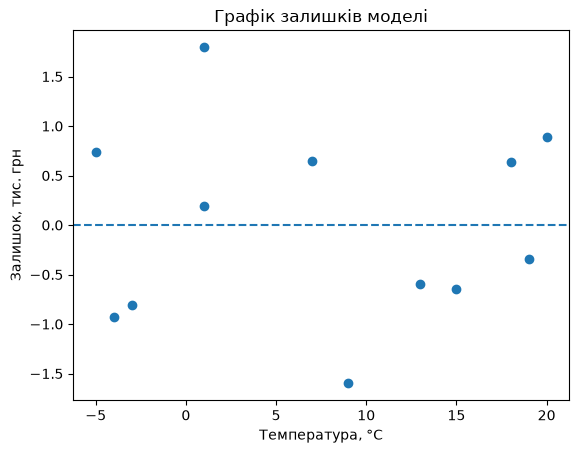


ЗАВДАННЯ 4
Мінімальна температура у наборі: -5 °C
Максимальна температура у наборі: 20 °C
Прогноз при температурі -10°C: 4.087 тис. грн

ЗАВДАННЯ 5
p-value linregress = 0.0032
p-value pearsonr = 0.0032


In [1]:
# Практика 17. Проста лінійна регресія
# Варіант 6 — Чернігів

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

# ============================================================
# ПОБУДОВА НАБОРУ ДАНИХ
# ============================================================

np.random.seed(6)

city = "Чернігів"
monthly_temp = [-5, -4, 1, 9, 15, 18, 20, 19, 13, 7, 1, -3]

months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
          "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0, 30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("НАБІР ДАНИХ")
display(climate)


# ============================================================
# ЗАВДАННЯ 1. ПОБУДОВА РЕГРЕСІЙНОЇ МОДЕЛІ
# ============================================================

x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

print("\nЗАВДАННЯ 1")
print(f"Нахил b1 = {result.slope:.3f}")
print(f"Перетин b0 = {result.intercept:.3f}")
print(f"R² = {result.rvalue ** 2:.3f}")
print(f"p-value = {result.pvalue:.4f}")

predicted = result.intercept + result.slope * x

print(
    f"\nРівняння регресії: "
    f"витрати ≈ {result.intercept:.3f} "
    f"+ ({result.slope:.3f}) × температура"
)

# Письмова відповідь:
# Для варіанта 6 отримано рівняння:
# витрати ≈ 2.829 - 0.126 × температура.
#
# Коефіцієнт нахилу b1 = -0.126 означає, що при збільшенні
# середньомісячної температури на 1°C прогнозовані витрати
# на опалення в середньому зменшуються приблизно на
# 0.126 тис. грн, тобто на 126 грн.
# Негативний знак нахилу є логічним, оскільки при вищій
# температурі потреба в опаленні загалом зменшується.


# ============================================================
# ЗАВДАННЯ 2. КОЕФІЦІЄНТ ДЕТЕРМІНАЦІЇ
# ============================================================

residuals = y - predicted

ss_residual = np.sum(residuals ** 2)
ss_total = np.sum((y - y.mean()) ** 2)

r2_method_1 = result.rvalue ** 2
r2_method_2 = 1 - ss_residual / ss_total

pearson_result = pearsonr(x, y)
r_squared_from_pearson = pearson_result.statistic ** 2

print("\nЗАВДАННЯ 2")
print(f"R² через result.rvalue ** 2 = {r2_method_1:.3f}")
print(f"R² через 1 - SS_залишків / SS_загальна = {r2_method_2:.3f}")
print(f"r² з Практики 16 = {r_squared_from_pearson:.3f}")
print(f"SS залишків = {ss_residual:.3f}")
print(f"SS загальна = {ss_total:.3f}")

# Письмова відповідь:
# R², обчислене двома способами, має однакове значення:
# приблизно 0.597.
# Значення r² з Практики 16 також дорівнює приблизно 0.597.
# Це підтверджує теоретичну властивість простої лінійної
# регресії з одним предиктором: R² = r².
#
# R² = 0.597 означає, що приблизно 59.7% розкиду витрат
# на опалення в цій вибірці пояснюється температурою
# за побудованою лінійною моделлю.
# Решта приблизно 40.3% варіації залишається непоясненою
# цією моделлю та пов'язана з іншими факторами і випадковими
# відхиленнями.


# ============================================================
# ЗАВДАННЯ 3. ГРАФІК ЗАЛИШКІВ
# ============================================================

fig, ax = plt.subplots()

ax.scatter(x, residuals)
ax.axhline(0, linestyle="--")

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Залишок, тис. грн")
ax.set_title("Графік залишків моделі")

plt.show()

# Письмова відповідь:
# На графіку залишків точки не утворюють ідеально випадкову
# хмару навколо нуля. Для теплих місяців частина залишків
# має тенденцію бути додатною, оскільки витрати в коді генерації
# не можуть бути меншими за нуль через використання max(cost, 0).
# Лінійна модель у теплі місяці може формально прогнозувати
# від'ємні значення витрат, тоді як фактичні значення обмежені
# нулем.
#
# Таким чином, нижнє обмеження cost на нуль може створювати
# певну структуру в залишках для найтепліших температур.
# Це показує, чому навіть досить помітне R² саме по собі
# не гарантує повної адекватності лінійної моделі.
# Графік залишків може виявити структуру, яку одне число R²
# не показує.


# ============================================================
# ЗАВДАННЯ 4. ПРОГНОЗ ПРИ -10°C
# ============================================================

temperature_new = -10

forecast = result.intercept + result.slope * temperature_new

min_temp = climate["температура"].min()
max_temp = climate["температура"].max()

print("\nЗАВДАННЯ 4")
print(f"Мінімальна температура у наборі: {min_temp} °C")
print(f"Максимальна температура у наборі: {max_temp} °C")
print(f"Прогноз при температурі -10°C: {forecast:.3f} тис. грн")

# Письмова відповідь:
# За рівнянням регресії при температурі -10°C прогнозовані
# витрати на опалення становлять приблизно 4.087 тис. грн.
#
# У наборі даних температура змінюється від -5°C до 20°C.
# Значення -10°C знаходиться за межами спостереженого діапазону,
# тому цей прогноз є екстраполяцією.
#
# Надійність такого прогнозу повинна бути нижчою, ніж прогнозу
# всередині спостереженого діапазону, оскільки модель не була
# перевірена на даних при температурах нижче -5°C.
# Ми припускаємо, що виявлена лінійна залежність продовжується
# за межами наявних даних, але це припущення може бути неправильним.


# ============================================================
# ЗАВДАННЯ 5. ПОРІВНЯННЯ З КОЕФІЦІЄНТОМ КОРЕЛЯЦІЇ
# ============================================================

print("\nЗАВДАННЯ 5")
print(f"p-value linregress = {result.pvalue:.4f}")
print(f"p-value pearsonr = {pearson_result.pvalue:.4f}")

# Письмова відповідь:
# p-value, отримане через linregress(), і p-value, отримане
# через pearsonr(), однакові або практично однакові.
# У цьому випадку обидва тести перевіряють пов'язану нульову
# гіпотезу про відсутність лінійного зв'язку.
#
# Для простої лінійної регресії з одним предиктором H0 про
# нульовий нахил регресії відповідає H0 про нульову кореляцію.
# Тому linregress() і pearsonr() дають однаковий висновок
# щодо статистичної значущості зв'язку.


# ============================================================
# КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

# 1. Чому метод найменших квадратів мінімізує саме суму
# квадратів залишків?
#
# Метод найменших квадратів мінімізує суму квадратів залишків,
# тому що квадрат робить усі відхилення невід'ємними та не дає
# позитивним і негативним помилкам взаємно компенсуватися.
# Крім того, великі помилки отримують більшу вагу.
# Квадратична функція є зручною для математичного пошуку
# мінімуму та дозволяє отримати однозначні оцінки параметрів
# лінійної моделі.


# 2. Що означає коефіцієнт нахилу b1 і чим він відрізняється
# від коефіцієнта кореляції r?
#
# Коефіцієнт нахилу b1 показує, на скільки одиниць змінюється
# прогнозоване значення Y при збільшенні X на одну одиницю.
# У цій роботі b1 = -0.126 тис. грн на 1°C.
# Коефіцієнт кореляції r показує напрямок і силу лінійного
# зв'язку та не має таких змістовних одиниць.
# Отже, b1 можна інтерпретувати у конкретних одиницях вимірювання,
# а r є стандартизованою мірою сили лінійного зв'язку.


# 3. Чому високий R² не гарантує адекватності лінійної моделі?
#
# Високий R² показує, яку частку варіації Y пояснює модель,
# але не показує всю структуру помилок.
# Графік залишків може виявити нелінійність, систематичну
# структуру або нерівномірний розкид залишків.
# Тому для оцінювання адекватності моделі потрібно аналізувати
# не лише R², а й графік залишків.


# 4. Що змінюється в надійності прогнозу при виході X
# за межі спостереженого діапазону?
#
# Якщо значення X виходить за межі спостереженого діапазону,
# прогноз стає екстраполяцією.
# Його надійність нижча, тому що модель не перевірена
# на даних у цій області.
# Неможливо автоматично припустити, що виявлена залежність
# продовжиться за межами наявних спостережень.

